# Exercise 1: Feature Scaling and Model Performance on Wine Dataset

**Dataset Overview:**
We are using the Wine dataset, which is a classic dataset in machine learning. It contains 178 samples of wine from 3 different cultivars (classes) and 13 chemical features measured for each wine, such as alcohol content, color intensity, flavanoids, etc.

The goal is to predict the wine cultivar (class 0, 1, or 2) based on these chemical measurements. If you are asking what is cultivar you can think like it shows which grape variety the wine sample belongs to.

**Challenge in this dataset:**
The features are on different scales. For example, alcohol content may range roughly between 11–14, while color intensity may range 1–13. This scale difference can bias distance-based models like KNN and kernel-based models like SVM if we don’t scale the data properly.

In [ ]:
# ====================================================
# Exercise 1: Impact of Feature Scaling on KNN and SVM

import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# ----------------------------
# Load dataset with features at different scales
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names


# Display feature statistics to show different scales
df = pd.DataFrame(X, columns=feature_names)
print("Feature Statistics (showing different scales):")
print(df.describe().loc[['min', 'max', 'mean', 'std']])
print("\n")


# ========================
# WITHOUT SCALING
print("=" * 60)
print("WITHOUT SCALING")
print("=" * 60)

# KNN without scaling
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
cv_scores_knn_no_scale = cross_val_score(knn_no_scale, X, y, cv=5)
print(f"KNN CV Accuracy (no scaling): {cv_scores_knn_no_scale.mean():.4f} (+/- {cv_scores_knn_no_scale.std():.4f})")
print("KNN CV fold accuracies (no scaling):", cv_scores_knn_no_scale)

# SVM without scaling
svm_no_scale = SVC(kernel='rbf', random_state=42)
cv_scores_svm_no_scale = cross_val_score(svm_no_scale, X, y, cv=5)
print(f"\nSVM CV Accuracy (no scaling): {cv_scores_svm_no_scale.mean():.4f} (+/- {cv_scores_svm_no_scale.std():.4f})")
print("SVM CV fold accuracies (no scaling):", cv_scores_svm_no_scale)
print("\n")

# ========================
# WITH SCALING
print("=" * 60)
print("WITH PROPER SCALING")
print("=" * 60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit + transform entire dataset

# KNN with scaling
knn_scale = KNeighborsClassifier(n_neighbors=5)
cv_scores_knn_scale = cross_val_score(knn_scale, X_scaled, y, cv=5)
print(f"KNN CV Accuracy (with scaling): {cv_scores_knn_scale.mean():.4f} (+/- {cv_scores_knn_scale.std():.4f})")
print("KNN CV fold accuracies (with scaling):", cv_scores_knn_scale)

# SVM with scaling
svm_scale = SVC(kernel='rbf', random_state=42)
cv_scores_svm_scale = cross_val_score(svm_scale, X_scaled, y, cv=5)
print(f"\nSVM CV Accuracy (with scaling): {cv_scores_svm_scale.mean():.4f} (+/- {cv_scores_svm_scale.std():.4f})")
print("SVM CV fold accuracies (with scaling):", cv_scores_svm_scale)
print("\n")

# ========================
# IMPROVEMENT SUMMARY
print("=" * 60)
print("IMPROVEMENT SUMMARY")
print("=" * 60)
print(f"KNN CV Improvement: {(cv_scores_knn_scale.mean() - cv_scores_knn_no_scale.mean()):.4f}")
print(f"SVM CV Improvement: {(cv_scores_svm_scale.mean() - cv_scores_svm_no_scale.mean()):.4f}")
print("\n")


Feature Statistics (showing different scales):
        alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity       hue  od280/od315_of_diluted_wines      proline
min   11.030000    0.740000  1.360000          10.600000   70.000000       0.980000    0.340000              0.130000         0.410000         1.280000  0.480000                      1.270000   278.000000
max   14.830000    5.800000  3.230000          30.000000  162.000000       3.880000    5.080000              0.660000         3.580000        13.000000  1.710000                      4.000000  1680.000000
mean  13.000618    2.336348  2.366517          19.494944   99.741573       2.295112    2.029270              0.361854         1.590899         5.058090  0.957449                      2.611685   746.893258
std    0.811827    1.117146  0.274344           3.339564   14.282484       0.625851    0.998859              0.124453         0.57235

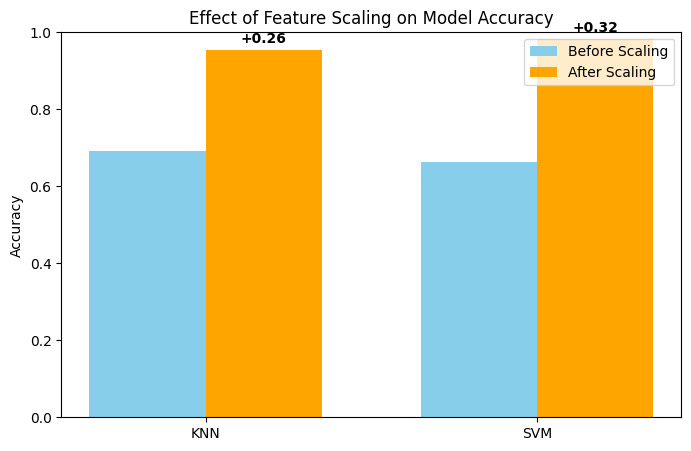

In [ ]:
import matplotlib.pyplot as plt

# Accuracy before and after scaling
models = ['KNN', 'SVM']
accuracy_before = [cv_scores_knn_no_scale.mean(), cv_scores_svm_no_scale.mean()]
accuracy_after = [cv_scores_knn_scale.mean(), cv_scores_svm_scale.mean()]
improvement = [accuracy_after[i] - accuracy_before[i] for i in range(2)]

# Bar plot
plt.figure(figsize=(8,5))
bar_width = 0.35
index = np.arange(len(models))

plt.bar(index, accuracy_before, bar_width, label='Before Scaling', color='skyblue')
plt.bar(index + bar_width, accuracy_after, bar_width, label='After Scaling', color='orange')

for i, val in enumerate(improvement):
    plt.text(i + bar_width, accuracy_after[i] + 0.01, f'+{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1)
plt.xticks(index + bar_width/2, models)
plt.ylabel('Accuracy')
plt.title('Effect of Feature Scaling on Model Accuracy')
plt.legend()
plt.show()

When we run KNN and SVM on the original dataset without scaling, the models achieve around 0.69 accuracy for KNN and 0.66 for SVM. However, after applying StandardScaler to standardize the features, the model accuracies improve by approximately 0.26 for KNN and 0.32 for SVM. This clearly demonstrates that feature scaling has a significant positive impact, especially for distance-based models like KNN and kernel-based models like SVM.

# Exercise 2: Class Imbalance Situtation on Fraud Detection Data (Skipped)

**Dataset Overview:**
We are using the Credit Card Fraud Detection dataset, which contains transactions labeled as fraudulent (1) or normal (0). The dataset includes many features extracted from transaction data, but the main goal is to predict whether a transaction is **fraudulent** or not. We will only use 20000 samples for faster experimentation.

**Imbalance Challenge:**

The dataset is highly imbalanced: the majority class ("Normal") dominates, while the minority class ("Fraud") is very small.

This imbalance makes it difficult for standard classifiers to correctly identify fraud cases. Models tend to predict the majority class most of the time, resulting in **high accuracy** but **poor recall** for the fraud class.

In [ ]:
# =========================================================
# EXERCISE 2 — IMBALANCE SITUATION: BASELINE, SMOTE, THRESHOLD

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ----------------------------
# Load REAL fraud dataset

X, y = fetch_openml("creditcard", version=1, as_frame=True, return_X_y=True)
y = y.astype(int)

# Subsample to speed up experiment demonstration
fraud_idx = np.where(y==1)[0]
normal_idx = np.where(y==0)[0][:20000]
idx = np.concatenate([fraud_idx, normal_idx])
X = X.iloc[idx]
y = y.iloc[idx]

print("Class distribution:", np.bincount(y))

X = X.values
y = y.values

# ----------------------------
# Helper function for cross validation and confusion matrix

def evaluate_with_cm(model, X, y):
    cv = StratifiedKFold(5, shuffle=True, random_state=42)
    recalls, precisions, f1s = [], [], []
    last_cm = None

    for tr, te in cv.split(X, y):
        model.fit(X[tr], y[tr])
        preds = model.predict(X[te])
        recalls.append(recall_score(y[te], preds))
        precisions.append(precision_score(y[te], preds))
        f1s.append(f1_score(y[te], preds))
        last_cm = confusion_matrix(y[te], preds)

    return np.mean(recalls), np.mean(precisions), np.mean(f1s), last_cm

# ----------------------------
# Helper function to plot confusion matrix

def plot_cm(cm, class_names=["Normal", "Fraud"], title="Confusion Matrix"):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(title)
    plt.show()

Class distribution: [20000   492]



===== BASELINE (Imbalanced Dataset) =====
Recall: 0.7196454339311483 Precision: 0.8887810152429607 F1: 0.7946633195655978


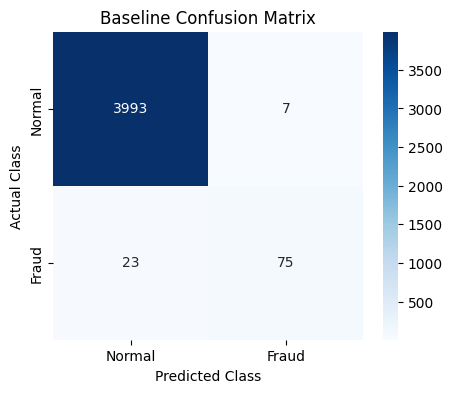

In [ ]:
# =====================================================
# 1. BASELINE: Logistic Regression on imbalanced data
print("\n===== BASELINE (Imbalanced Dataset) =====")
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

r, p, f, cm = evaluate_with_cm(baseline, X, y)
print("Recall:", r, "Precision:", p, "F1:", f)
plot_cm(cm, class_names=["Normal", "Fraud"], title="Baseline Confusion Matrix")

When we train Logistic Regression on the original imbalanced dataset, the model fails to detect some number of fraud cases.

In our example, it misses 23 fraudulent transactions, which directly leads to a low recall score. This happens because the model is biased toward the majority class and does not learn enough about the minority (fraud) class.

One way to address this issue is to increase the number of samples in the minority class. To achieve this, we apply the SMOTE technique, which we previously discussed in the lecture, and then retrain Logistic Regression on the resulting balanced dataset.

The `sampling_strategy` parameter in SMOTE controls how the balancing is performed. By default (`"auto"`), SMOTE generates synthetic minority samples until the minority class size matches that of the majority class.

After applying SMOTE and re-evaluating the model, we observe that it identifies fraudulent cases more effectively.

As a result, the recall score improves, showing that the model is now better at capturing fraud instances.


===== SMOTE: Oversampling Minority Class =====
Recall: 0.9248402391259534 Precision: 0.47635042672819317 F1: 0.6282848676179729


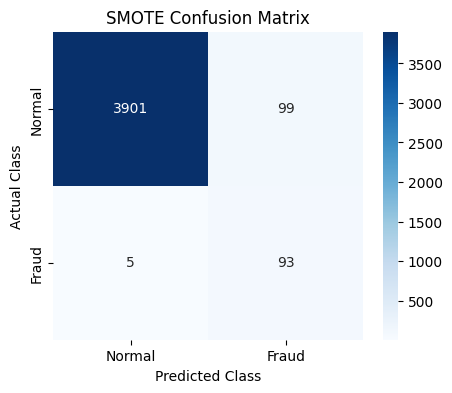

In [ ]:
# =====================================================
# 2. SMOTE: Balance the dataset
print("\n===== SMOTE: Oversampling Minority Class =====")

from collections import Counter

smote = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(sampling_strategy='auto', random_state=42)),
    ("model", LogisticRegression(max_iter=2000))
])


# Evaluate model with cross-validation
r, p, f, cm = evaluate_with_cm(smote, X, y)
print("Recall:", r, "Precision:", p, "F1:", f)
plot_cm(cm, class_names=["Normal", "Fraud"], title="SMOTE Confusion Matrix")


BUT DO YOU THINK THERE IS ANOTHER ALTERNATIVE WHILE WORKING WITH IMBALANCE CASES?

Actually we kind of have if you remember the previous lecture and lab session about thresholds.

By default, Logistic Regression uses a probability threshold of 0.5 to classify a transaction as fraud. In imbalanced problems, this often causes many fraud cases to be missed.

Instead of changing the data distribution, we can adjust this decision threshold to make the model more sensitive to the minority class.

By changing the model's threshold we could have a better recall for the minority class.

The key takeaway is that imbalanced classification does not have a single solution. Besides resampling methods like SMOTE, threshold tuning is another effective strategy, and in practice both approaches can be used.


===== THRESHOLD TUNING (Adjusting Logistic Regression Decision Threshold) =====
Threshold 0.7 => Recall: 0.669, Precision: 0.905, F1: 0.768


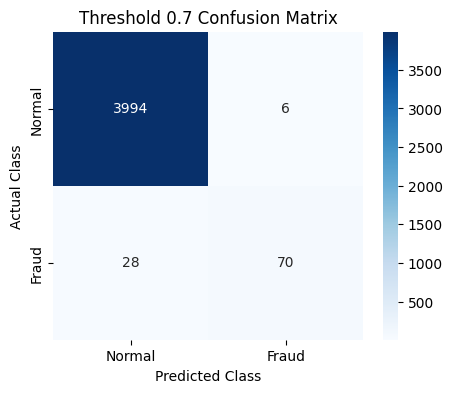

Threshold 0.3 => Recall: 0.793, Precision: 0.862, F1: 0.825


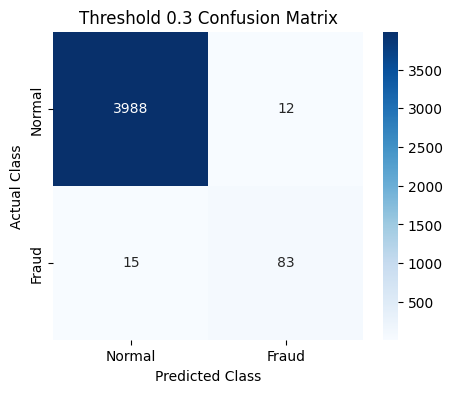

Threshold 0.1 => Recall: 0.884, Precision: 0.721, F1: 0.793


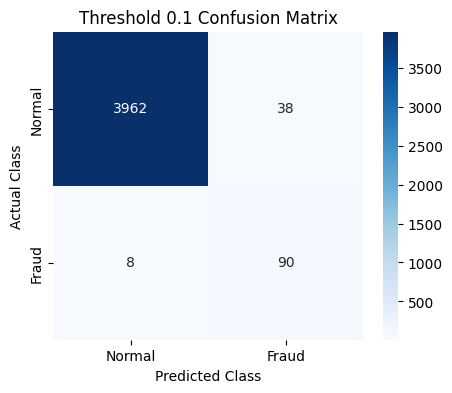

In [ ]:
# =====================================================
# 3. THRESHOLD TUNING: Adjust probability threshold

print("\n===== THRESHOLD TUNING (Adjusting Logistic Regression Decision Threshold) =====")
thresholds = [0.7, 0.3, 0.1]  # Default, moderate, aggressive

for t in thresholds:
    cv = StratifiedKFold(5, shuffle=True, random_state=42)
    recalls, precisions, f1s = [], [], []
    last_cm = None
    for tr, te in cv.split(X, y):
        model = LogisticRegression(max_iter=2000)
        model.fit(X[tr], y[tr])
        probs = model.predict_proba(X[te])[:,1]
        preds = (probs > t).astype(int)
        recalls.append(recall_score(y[te], preds))
        precisions.append(precision_score(y[te], preds))
        f1s.append(f1_score(y[te], preds))
        last_cm = confusion_matrix(y[te], preds)
    print(f"Threshold {t} => Recall: {np.mean(recalls):.3f}, Precision: {np.mean(precisions):.3f}, F1: {np.mean(f1s):.3f}")
    plot_cm(last_cm, class_names=["Normal", "Fraud"], title=f"Threshold {t} Confusion Matrix")


# Exercise 3: Feature Engineering on Madelon Dataset

Imagine you are handed a dataset with 500 features, but only 20 of them actually matter. The rest? Pure noise. Welcome to the Madelon dataset, a deliberately tricky artificial dataset designed to show how irrelevant features can sabotage your models.

Your task is simple in theory: predict the class. But in practice, it’s a test of your ability to separate signal from noise.

In [ ]:
# Exercise 3: Feature Engineering - Removing Unnecessary Features
# Using Madelon dataset with cross-validation
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import time
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Load Madelon dataset
print("Loading Madelon dataset (designed with irrelevant features)...")
data = fetch_openml(name='madelon', version=1, as_frame=True, parser='auto')
X = data.data
y = data.target

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

print("=" * 60)
print("DATASET: Madelon (Artificial with Many Irrelevant Features)")
print("=" * 60)
print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")
print("NOTE: This dataset was specifically designed with:")
print("  - 20 informative features")
print("  - 480 irrelevant/noise features")
print("  - Goal: Show importance of feature selection")
print("\n")

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Loading Madelon dataset (designed with irrelevant features)...
DATASET: Madelon (Artificial with Many Irrelevant Features)
Total features: 500
Total samples: 2600
NOTE: This dataset was specifically designed with:
  - 20 informative features
  - 480 irrelevant/noise features
  - Goal: Show importance of feature selection




### Using all 500 features

We start naive: feed all features into our models.

**Outcome:** accuracy is mediocre, F1-scores are low, and training takes longer.

Why?

The models are drowning in irrelevant features and trying to “memorize” noise. Cross-validation results fluctuate, showing unstable performance.

In [ ]:
# STRATEGY 1: Using ALL features with cross-validation
print("=" * 60)
print("STRATEGY 1: USING ALL 500 FEATURES")
print("=" * 60)

models_all_features = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results_all = []

for name, model in models_all_features.items():
    print(f"Training {name} with all features...")
    start_time = time.time()

    cv_accuracy = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(model, X, y, cv=cv, scoring='f1')

    training_time = time.time() - start_time

    results_all.append({
        'Model': name,
        'Features': 'All (500)',
        'CV Accuracy': cv_accuracy.mean(),
        'CV Accuracy Std': cv_accuracy.std(),
        'CV F1': cv_f1.mean(),
        'CV F1 Std': cv_f1.std(),
        'Time (s)': training_time
    })

    print(f"  CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
    print(f"  CV F1: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
    print(f"  Time: {training_time:.2f}s")

print("\n")

STRATEGY 1: USING ALL 500 FEATURES
Training Logistic Regression with all features...
  CV Accuracy: 0.5512 (+/- 0.0162)
  CV F1: 0.5571 (+/- 0.0259)
  Time: 96.78s
Training Random Forest with all features...
  CV Accuracy: 0.7077 (+/- 0.0244)
  CV F1: 0.7133 (+/- 0.0245)
  Time: 40.50s




### Selecting the top 50 features

Next, we apply feature selection using SelectKBest.

It measures how different feature values are across classes.
High score = feature separates classes well.

Now the models see mostly informative features.

**Outcome:** accuracy and F1-score improve significantly, training is faster, and results are more consistent across folds.

**Insight:** reducing noise allows the model to focus on meaningful patterns rather than chasing irrelevant fluctuations.

In [ ]:
# STRATEGY 2: Feature selection (50 features) with cross-validation
print("=" * 60)
print("STRATEGY 2: FEATURE SELECTION (TOP 50 FEATURES)")
print("=" * 60)

models_selected_50 = {
    'Logistic Regression': Pipeline([
        ('selector', SelectKBest(f_classif, k=50)),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('selector', SelectKBest(f_classif, k=50)),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

results_selected_50 = []

for name, pipeline in models_selected_50.items():
    print(f"Training {name} with top 50 features...")
    start_time = time.time()

    cv_accuracy = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

    training_time = time.time() - start_time

    results_selected_50.append({
        'Model': name,
        'Features': 'Selected (50)',
        'CV Accuracy': cv_accuracy.mean(),
        'CV Accuracy Std': cv_accuracy.std(),
        'CV F1': cv_f1.mean(),
        'CV F1 Std': cv_f1.std(),
        'Time (s)': training_time
    })

    print(f"  CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
    print(f"  CV F1: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
    print(f"  Time: {training_time:.2f}s")

print("\n")

STRATEGY 2: FEATURE SELECTION (TOP 50 FEATURES)
Training Logistic Regression with top 50 features...
  CV Accuracy: 0.5754 (+/- 0.0253)
  CV F1: 0.5787 (+/- 0.0277)
  Time: 8.16s
Training Random Forest with top 50 features...
  CV Accuracy: 0.7923 (+/- 0.0147)
  CV F1: 0.7978 (+/- 0.0157)
  Time: 14.43s




### Selecting the top 20 features

Finally, we get laser-focused, selecting only the 20 most informative features.

**Outcome:** this gives the best performance. Accuracy and F1 are highest, and training is lightning-fast. Standard deviations across folds are minimal.

**Insight:** the right set of features not only boosts performance but also stabilizes your model’s learning.

In [ ]:
# STRATEGY 2: Feature selection (50 features) with cross-validation
print("=" * 60)
print("STRATEGY 2: FEATURE SELECTION (TOP 50 FEATURES)")
print("=" * 60)

models_selected_20 = {
    'Logistic Regression': Pipeline([
        ('selector', SelectKBest(f_classif, k=20)),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('selector', SelectKBest(f_classif, k=20)),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

results_selected_20 = []

for name, pipeline in models_selected_20.items():
    print(f"Training {name} with top 20 features...")
    start_time = time.time()

    cv_accuracy = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

    training_time = time.time() - start_time

    results_selected_20.append({
        'Model': name,
        'Features': 'Selected (20)',
        'CV Accuracy': cv_accuracy.mean(),
        'CV Accuracy Std': cv_accuracy.std(),
        'CV F1': cv_f1.mean(),
        'CV F1 Std': cv_f1.std(),
        'Time (s)': training_time
    })

    print(f"  CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
    print(f"  CV F1: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
    print(f"  Time: {training_time:.2f}s")

print("\n")

STRATEGY 2: FEATURE SELECTION (TOP 50 FEATURES)
Training Logistic Regression with top 20 features...
  CV Accuracy: 0.5804 (+/- 0.0242)
  CV F1: 0.5772 (+/- 0.0243)
  Time: 4.47s
Training Random Forest with top 20 features...
  CV Accuracy: 0.8573 (+/- 0.0125)
  CV F1: 0.8583 (+/- 0.0124)
  Time: 9.54s




COMPARISON SUMMARY
              Model      Features  CV Accuracy  CV Accuracy Std    CV F1  CV F1 Std  Time (s)
Logistic Regression     All (500)     0.551154         0.016209 0.557131   0.025939 96.781527
      Random Forest     All (500)     0.707692         0.024447 0.713350   0.024470 40.500828
Logistic Regression Selected (50)     0.575385         0.025291 0.578671   0.027668  8.155073
      Random Forest Selected (50)     0.792308         0.014746 0.797794   0.015659 14.426420
Logistic Regression Selected (20)     0.580385         0.024216 0.577237   0.024291  4.472568
      Random Forest Selected (20)     0.857308         0.012546 0.858344   0.012420  9.540645

KEY TAKEAWAYS
1. Using ALL features (including 480 irrelevant ones) HURTS performance
2. Feature selection IMPROVES accuracy and reduces overfitting
3. Selecting the right number of features is important (20-50 work well)
4. Feature selection also SPEEDS UP training time significantly
5. This dataset proves irrelevant fe

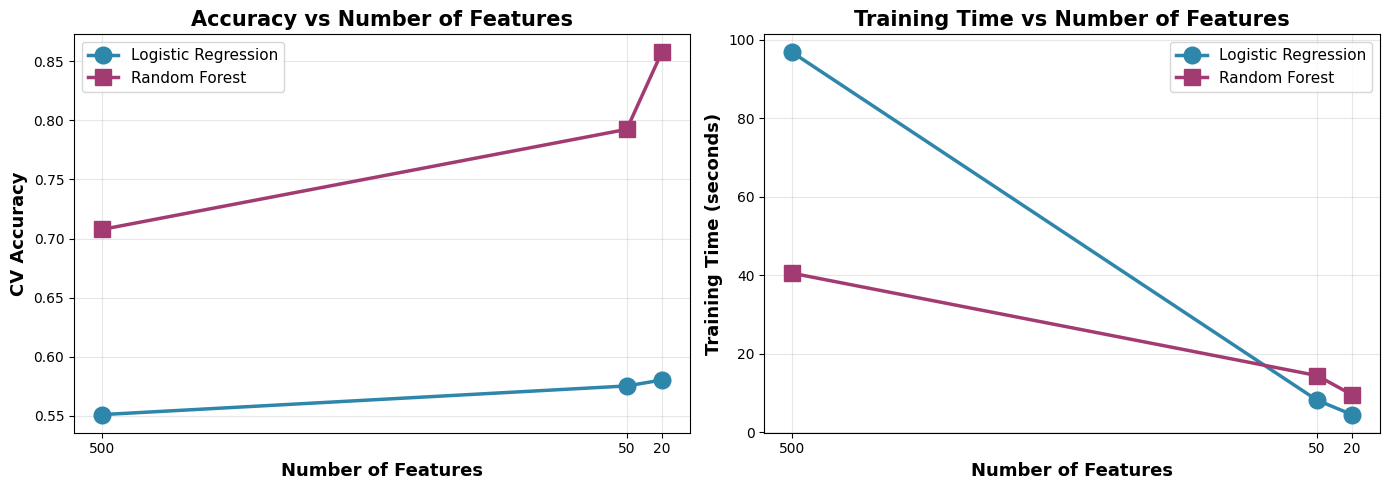

In [ ]:
# COMPARISON
print("=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)
import matplotlib.pyplot as plt
import seaborn as sns


all_results = results_all + results_selected_50 + results_selected_20
df_results = pd.DataFrame(all_results)
print(df_results.to_string(index=False))


print("KEY TAKEAWAYS")
print("=" * 60)
print("1. Using ALL features (including 480 irrelevant ones) HURTS performance")
print("2. Feature selection IMPROVES accuracy and reduces overfitting")
print("3. Selecting the right number of features is important (20-50 work well)")
print("4. Feature selection also SPEEDS UP training time significantly")
print("5. This dataset proves irrelevant features harm model performance!")


# ============================================================
# PLOTTING


# Extract data for plotting
features = [500, 50, 20]

lr_accuracy = []
lr_time = []
rf_accuracy = []
rf_time = []

for results in [results_all, results_selected_50, results_selected_20]:
    for r in results:
        if r['Model'] == 'Logistic Regression':
            lr_accuracy.append(r['CV Accuracy'])
            lr_time.append(r['Time (s)'])
        else:
            rf_accuracy.append(r['CV Accuracy'])
            rf_time.append(r['Time (s)'])

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Features
ax1.plot(features, lr_accuracy, 'o-', linewidth=2.5, markersize=12,
         label='Logistic Regression', color='#2E86AB')
ax1.plot(features, rf_accuracy, 's-', linewidth=2.5, markersize=12,
         label='Random Forest', color='#A23B72')
ax1.set_xlabel('Number of Features', fontsize=13, fontweight='bold')
ax1.set_ylabel('CV Accuracy', fontsize=13, fontweight='bold')
ax1.set_title('Accuracy vs Number of Features', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()
ax1.set_xticks([500, 50, 20])

# Plot 2: Time vs Features
ax2.plot(features, lr_time, 'o-', linewidth=2.5, markersize=12,
         label='Logistic Regression', color='#2E86AB')
ax2.plot(features, rf_time, 's-', linewidth=2.5, markersize=12,
         label='Random Forest', color='#A23B72')
ax2.set_xlabel('Number of Features', fontsize=13, fontweight='bold')
ax2.set_ylabel('Training Time (seconds)', fontsize=13, fontweight='bold')
ax2.set_title('Training Time vs Number of Features', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()
ax2.set_xticks([500, 50, 20])

plt.tight_layout()
plt.savefig('feature_selection_results.png', dpi=300, bbox_inches='tight')
plt.show()


The story here is clear: more features is not always better.

Irrelevant features can mislead models, increase overfitting, and waste computation. Feature selection is like giving the model a clean, focused map to the solution.

# Exercise 4: Power of Ensemble Models on Cover Type Dataset

The Forest Cover Type dataset comes from the US Forest Service and contains
cartographic data for 30x30 meter cells in Roosevelt National Forest, Colorado.
The goal is to predict the forest cover type (7 different tree species) based
on wilderness area, soil type, and topographical features.


In [ ]:
# Exercise 4: Why Ensemble Models and When to Use Each
# Using datasets where ensemble models clearly outperform traditional models
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import time

print("=" * 60)
print("DEMONSTRATING ENSEMBLE SUPERIORITY")

print("\n")

# ============================================================
# DATASET: COVERTYPE - High dimensional, complex patterns

print("=" * 60)
print("DATASET 1: Forest Cover Type (Complex Multi-class)")
print("=" * 60)
print("This dataset has:")
print("  - 54 features (mix of continuous and binary)")
print("  - 7 classes (types of forest cover)")
print("  - Complex non-linear decision boundaries")
print("  - High feature interactions")
print("\n")

# Load covertype dataset
data = fetch_openml(name='covertype', version=3, as_frame=True, parser='auto')
X = data.data
y = data.target

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Take a sample for computational efficiency
from sklearn.model_selection import train_test_split as split_sample
X_sample, _, y_sample, _ = split_sample(X, y, train_size=5000, random_state=42, stratify=y)

print(f"Using {len(X_sample)} samples")
print(f"Features: {X_sample.shape[1]}")
print(f"Classes: {len(np.unique(y_sample))}")
print("\n")

# Handle any missing values
X_sample = SimpleImputer(strategy='mean').fit_transform(X_sample)

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models
models_covertype = {
    # Traditional Models
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=500),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM (Linear)': SVC(kernel='linear', random_state=42),

    # Ensemble Models
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, max_depth=5, eval_metric='mlogloss')
}

results_covertype = []

print("Training and evaluating models on Cover Type dataset...")
print("-" * 60)

for name, model in models_covertype.items():
    print(f"Evaluating {name}...", end=" ")
    start_time = time.time()

    try:
        cv_accuracy = cross_val_score(model, X_sample, y_sample, cv=cv, scoring='accuracy', n_jobs=-1)
        cv_f1 = cross_val_score(model, X_sample, y_sample, cv=cv, scoring='f1_weighted', n_jobs=-1)

        training_time = time.time() - start_time

        results_covertype.append({
            'Model': name,
            'CV Accuracy': cv_accuracy.mean(),

            'CV F1': cv_f1.mean(),

            'Time (s)': training_time
        })

        print(f"Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
    except Exception as e:
        print(f"Failed: {e}")

df_covertype = pd.DataFrame(results_covertype)
df_covertype = df_covertype.sort_values('CV Accuracy', ascending=False)

print("\n" + "=" * 60)
print("RESULTS: Cover Type Dataset")
print("=" * 60)
print(df_covertype.to_string(index=False))

print("\n" + "=" * 60)
print("ANALYSIS - Cover Type")
print("=" * 60)

traditional = df_covertype[df_covertype['Model'].isin(['Logistic Regression', 'KNN', 'SVM (Linear)'])]
ensemble = df_covertype[~df_covertype['Model'].isin(['Logistic Regression', 'KNN', 'SVM (Linear)'])]

print(f"\nBest Traditional Model: {traditional.iloc[0]['Model']}")
print(f"  Accuracy: {traditional.iloc[0]['CV Accuracy']:.4f}")
print(f"\nBest Ensemble Model: {ensemble.iloc[0]['Model']}")
print(f"  Accuracy: {ensemble.iloc[0]['CV Accuracy']:.4f}")
print(f"\nImprovement: {(ensemble.iloc[0]['CV Accuracy'] - traditional.iloc[0]['CV Accuracy']):.4f}")
print(f"Relative gain: {((ensemble.iloc[0]['CV Accuracy'] / traditional.iloc[0]['CV Accuracy'] - 1) * 100):.2f}%")

print("\n\n")

DEMONSTRATING ENSEMBLE SUPERIORITY


DATASET 1: Forest Cover Type (Complex Multi-class)
This dataset has:
  - 54 features (mix of continuous and binary)
  - 7 classes (types of forest cover)
  - Complex non-linear decision boundaries
  - High feature interactions


Using 5000 samples
Features: 54
Classes: 7


Training and evaluating models on Cover Type dataset...
------------------------------------------------------------
Evaluating Logistic Regression... Accuracy: 0.7170 (+/- 0.0064)
Evaluating KNN... Accuracy: 0.7316 (+/- 0.0119)
Evaluating SVM (Linear)... Accuracy: 0.7158 (+/- 0.0115)
Evaluating Random Forest... Accuracy: 0.7608 (+/- 0.0101)
Evaluating Gradient Boosting... Accuracy: 0.7622 (+/- 0.0133)
Evaluating XGBoost... Accuracy: 0.7710 (+/- 0.0132)

RESULTS: Cover Type Dataset
              Model  CV Accuracy    CV F1   Time (s)
            XGBoost       0.7710 0.765573   9.513211
  Gradient Boosting       0.7622 0.755914 154.548663
      Random Forest       0.7608 0.749969  

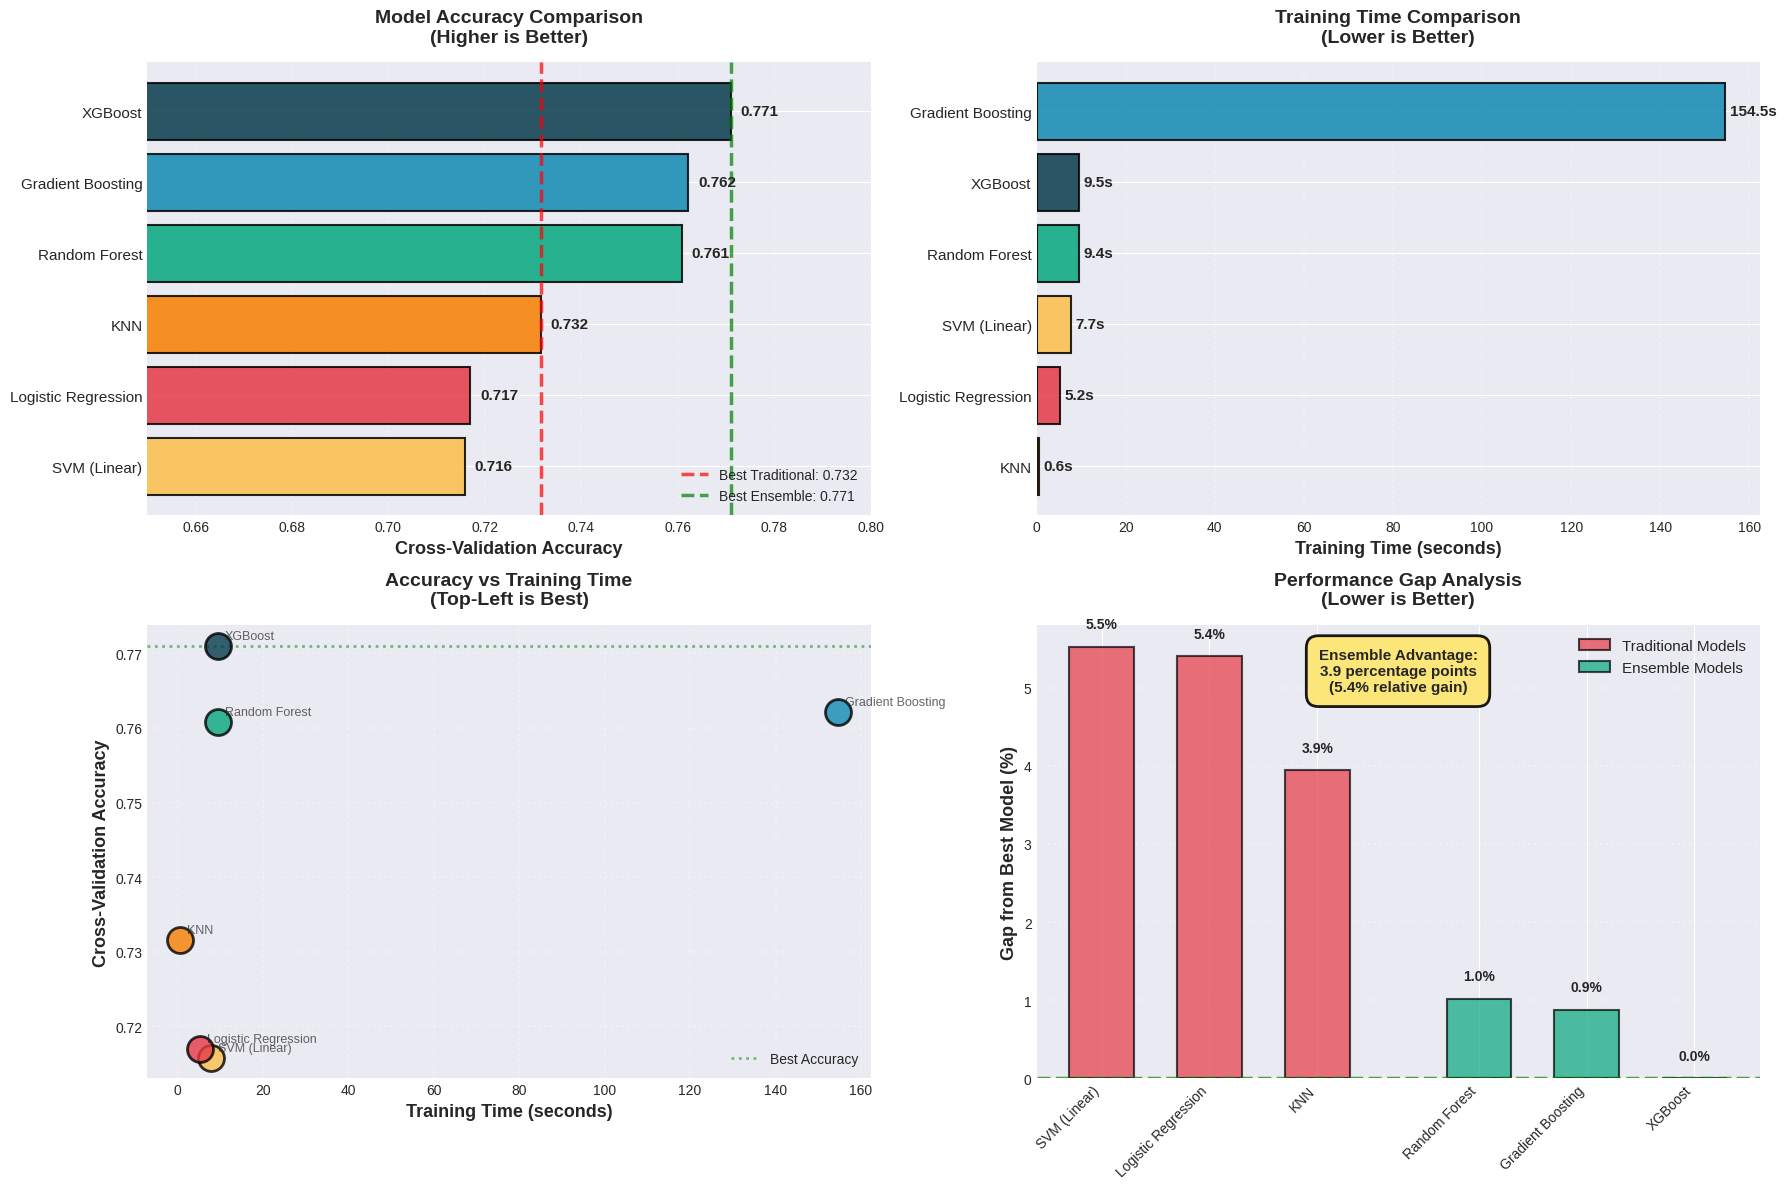

In [ ]:
# ============================================================
# ENSEMBLE VISUALIZATION

import matplotlib.pyplot as plt
import numpy as np

# Create figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
plt.style.use('seaborn-v0_8-whitegrid')

# Define colors for model categories
model_colors = {
    'Logistic Regression': '#E63946',     # Red - Traditional
    'KNN': '#F77F00',                      # Orange - Traditional
    'SVM (Linear)': '#FCBF49',             # Yellow - Traditional
    'Random Forest': '#06A77D',            # Green - Ensemble
    'Gradient Boosting': '#118AB2',        # Blue - Ensemble
    'XGBoost': '#073B4C'                   # Dark Blue - Ensemble (best)
}

# Sort results by accuracy
df_sorted = df_covertype.sort_values('CV Accuracy', ascending=True)

models = df_sorted['Model'].tolist()
accuracies = df_sorted['CV Accuracy'].tolist()
times = df_sorted['Time (s)'].tolist()
f1_scores = df_sorted['CV F1'].tolist()

# ============================================================
# PLOT 1: Accuracy Comparison (Horizontal Bar Chart)
y_pos = np.arange(len(models))
colors_list = [model_colors[m] for m in models]

bars = ax1.barh(y_pos, accuracies, color=colors_list, edgecolor='black', linewidth=1.5, alpha=0.85)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    width = bar.get_width()
    ax1.text(width + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc:.3f}', ha='left', va='center', fontsize=11, fontweight='bold')

# Add vertical line for best traditional model
best_trad_acc = traditional.iloc[0]['CV Accuracy']
ax1.axvline(x=best_trad_acc, color='red', linestyle='--', linewidth=2.5,
            label=f'Best Traditional: {best_trad_acc:.3f}', alpha=0.7)

# Add vertical line for best ensemble
best_ens_acc = ensemble.iloc[0]['CV Accuracy']
ax1.axvline(x=best_ens_acc, color='green', linestyle='--', linewidth=2.5,
            label=f'Best Ensemble: {best_ens_acc:.3f}', alpha=0.7)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(models, fontsize=11)
ax1.set_xlabel('Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax1.set_title('Model Accuracy Comparison\n(Higher is Better)', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax1.set_xlim([0.65, 0.80])
ax1.grid(axis='x', alpha=0.3, linestyle=':', linewidth=1.5)

# ============================================================
# PLOT 2: Training Time Comparison
df_time_sorted = df_covertype.sort_values('Time (s)', ascending=True)
models_time = df_time_sorted['Model'].tolist()
times_sorted = df_time_sorted['Time (s)'].tolist()
colors_time = [model_colors[m] for m in models_time]

y_pos_time = np.arange(len(models_time))
bars_time = ax2.barh(y_pos_time, times_sorted, color=colors_time,
                     edgecolor='black', linewidth=1.5, alpha=0.85)

# Add value labels
for bar, t in zip(bars_time, times_sorted):
    width = bar.get_width()
    ax2.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{t:.1f}s', ha='left', va='center', fontsize=11, fontweight='bold')

ax2.set_yticks(y_pos_time)
ax2.set_yticklabels(models_time, fontsize=11)
ax2.set_xlabel('Training Time (seconds)', fontsize=13, fontweight='bold')
ax2.set_title('Training Time Comparison\n(Lower is Better)', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle=':', linewidth=1.5)

# ============================================================
# PLOT 3: Accuracy vs Time Scatter=
for model, acc, time_val in zip(models, accuracies, times):
    ax3.scatter(time_val, acc, s=350, color=model_colors[model],
                edgecolors='black', linewidth=2, alpha=0.8, zorder=3)
    ax3.annotate(model, (time_val, acc), xytext=(5, 5),
                textcoords='offset points', fontsize=9, alpha=0.7)

# Draw efficiency frontier (top-left is best)
ax3.axhline(y=best_ens_acc, color='green', linestyle=':', linewidth=2, alpha=0.5, label='Best Accuracy')

ax3.set_xlabel('Training Time (seconds)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax3.set_title('Accuracy vs Training Time\n(Top-Left is Best)', fontsize=14, fontweight='bold', pad=15)
ax3.grid(True, alpha=0.3, linestyle=':', linewidth=1.5)
ax3.legend(loc='lower right', fontsize=10)

# ============================================================
# PLOT 4: Performance Gap Visualization
# Calculate gaps from best ensemble
best_acc = df_covertype['CV Accuracy'].max()
gaps = [(best_acc - acc) * 100 for acc in accuracies]  # Convert to percentage points

# Create grouped bar chart
traditional_mask = df_sorted['Model'].isin(['Logistic Regression', 'KNN', 'SVM (Linear)'])
ensemble_mask = ~traditional_mask

trad_models = df_sorted[traditional_mask]['Model'].tolist()
trad_gaps = [gaps[i] for i, m in enumerate(models) if m in trad_models]

ens_models = df_sorted[ensemble_mask]['Model'].tolist()
ens_gaps = [gaps[i] for i, m in enumerate(models) if m in ens_models]

x_trad = np.arange(len(trad_models))
x_ens = np.arange(len(ens_models))

ax4.bar(x_trad, trad_gaps, color='#E63946', alpha=0.7, edgecolor='black',
        linewidth=1.5, label='Traditional Models', width=0.6)
ax4.bar(x_ens + len(trad_models) + 0.5, ens_gaps, color='#06A77D', alpha=0.7,
        edgecolor='black', linewidth=1.5, label='Ensemble Models', width=0.6)

# Add value labels
for i, (gap, model) in enumerate(zip(trad_gaps, trad_models)):
    ax4.text(i, gap + 0.2, f'{gap:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
for i, (gap, model) in enumerate(zip(ens_gaps, ens_models)):
    ax4.text(i + len(trad_models) + 0.5, gap + 0.2, f'{gap:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Set x-axis labels
all_x = list(x_trad) + [len(trad_models) + 0.5 + i for i in x_ens]
all_labels = trad_models + ens_models
ax4.set_xticks(all_x)
ax4.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=10)
ax4.set_ylabel('Gap from Best Model (%)', fontsize=13, fontweight='bold')
ax4.set_title('Performance Gap Analysis\n(Lower is Better)', fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1.5)
ax4.axhline(y=0, color='green', linestyle='--', linewidth=2.5, alpha=0.7)

# Add annotation
gap_improvement = (best_trad_acc - best_ens_acc) * -100
textstr = f'Ensemble Advantage:\n{gap_improvement:.1f} percentage points\n({((best_ens_acc/best_trad_acc - 1) * 100):.1f}% relative gain)'
props = dict(boxstyle='round,pad=0.8', facecolor='#FFE66D', alpha=0.9, edgecolor='black', linewidth=2)
ax4.text(0.5, 0.95, textstr, transform=ax4.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='center', bbox=props, fontweight='bold')

plt.tight_layout()
plt.savefig('ensemble_comparison_covertype.png', dpi=300, bbox_inches='tight')
plt.show()